# 04 — Diễn giải model và phân tích lỗi

Việc diễn giải không làm thay đổi model đã chọn. Permutation importance được tính trên validation cho candidate ML truyền thống tốt nhất, còn dự báo trên holdout chỉ dùng để phân tích lỗi sau lựa chọn.

In [1]:
import json
import os
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MPL_CONFIG = ROOT / ".matplotlib"
MPL_CONFIG.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPL_CONFIG)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
# Run minh hoạ mặc định dùng VIC; pipeline nhận ticker khác qua config/CLI.
DATA_PATH = ROOT / "data" / "raw" / "VIC_VN.csv"
REPORT_DIR = ROOT / "evaluation"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)


FEATURES = [
    "return_1d", "return_5d", "volatility_10", "volatility_20",
    "volume_z_20", "rsi_14", "macd_scaled", "price_ma20", "price_ma50",
]
TARGET = "target_return_5d"

def build_frame(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy().sort_values("date").drop_duplicates("date").reset_index(drop=True)
    close = pd.to_numeric(df["close"], errors="coerce")
    volume = pd.to_numeric(df["volume"], errors="coerce")
    returns = np.log(close / close.shift(1))
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / 14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / 14, adjust=False).mean()
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    df["return_1d"] = returns
    df["return_5d"] = np.log(close / close.shift(5))
    df["volatility_10"] = returns.rolling(10).std()
    df["volatility_20"] = returns.rolling(20).std()
    df["volume_z_20"] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std()
    df["rsi_14"] = (100 - 100 / (1 + gain / loss.replace(0, np.nan))) / 100
    df["macd_scaled"] = macd / close
    df["price_ma20"] = close / close.rolling(20).mean() - 1
    df["price_ma50"] = close / close.rolling(50).mean() - 1
    df[TARGET] = np.log(close.shift(-5) / close)
    return df.replace([np.inf, -np.inf], np.nan)

In [2]:
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
frame = build_frame(raw).dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
n = len(frame); train_end, validation_end = int(n * .60), int(n * .80)
train, validation = frame.iloc[:train_end], frame.iloc[train_end:validation_end]
metrics_report = json.loads((REPORT_DIR / "model_metrics.json").read_text(encoding="utf-8"))
traditional_rows = [x for x in metrics_report["validation"] if x["model"] in {"ridge", "extra_trees", "hist_gradient_boosting"}]
interpreted_name = min(traditional_rows, key=lambda x: x["mae"])["model"]
estimators = {
    "ridge": Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10.0))]),
    "extra_trees": ExtraTreesRegressor(n_estimators=250, min_samples_leaf=8, max_features=.8, random_state=SEED, n_jobs=1),
    "hist_gradient_boosting": HistGradientBoostingRegressor(max_iter=200, max_leaf_nodes=15, learning_rate=.04, l2_regularization=1.0, random_state=SEED),
}
interpreted = estimators[interpreted_name].fit(train[FEATURES], train[TARGET])
perm = permutation_importance(interpreted, validation[FEATURES], validation[TARGET], scoring="neg_mean_absolute_error", n_repeats=15, random_state=SEED)
importance = pd.DataFrame({"feature": FEATURES, "mae_increase": perm.importances_mean, "std": perm.importances_std}).sort_values("mae_increase", ascending=False)
print("Model truyền thống được diễn giải:", interpreted_name)
importance

Model truyền thống được diễn giải: ridge


,feature,mae_increase,std
6,macd_scaled,0.005539,0.000707
8,price_ma50,0.001509,0.000406
3,volatility_20,0.000772,0.000079
5,rsi_14,0.000621,0.000372
7,price_ma20,0.000094,0.000131
1,return_5d,0.000047,0.000089
0,return_1d,-0.000010,0.000093
4,volume_z_20,-0.000081,0.000121
2,volatility_10,-0.000134,0.000124


In [3]:
preds = pd.read_csv(REPORT_DIR / "holdout_predictions.csv", parse_dates=["date"])
preds["error"] = preds["prediction"] - preds["actual"]
preds["absolute_error"] = preds["error"].abs()
preds["actual_band"] = pd.qcut(preds["actual"], 3, labels=["down", "flat", "up"])
preds["volatility_regime"] = pd.qcut(preds["actual"].abs(), 3, labels=["low", "medium", "high"])
error_by_band = preds.groupby("actual_band", observed=True).agg(rows=("actual", "size"), mae=("absolute_error", "mean"), bias=("error", "mean"))
error_by_volatility = preds.groupby("volatility_regime", observed=True).agg(rows=("actual", "size"), mae=("absolute_error", "mean"))
display(error_by_band)
display(error_by_volatility)

,rows,mae,bias
actual_band,,,
down,148,0.038543,0.029451
flat,145,0.041005,-0.036627
up,146,0.140097,-0.140097


,rows,mae
volatility_regime,,
low,147,0.020784
medium,146,0.057937
high,146,0.141028


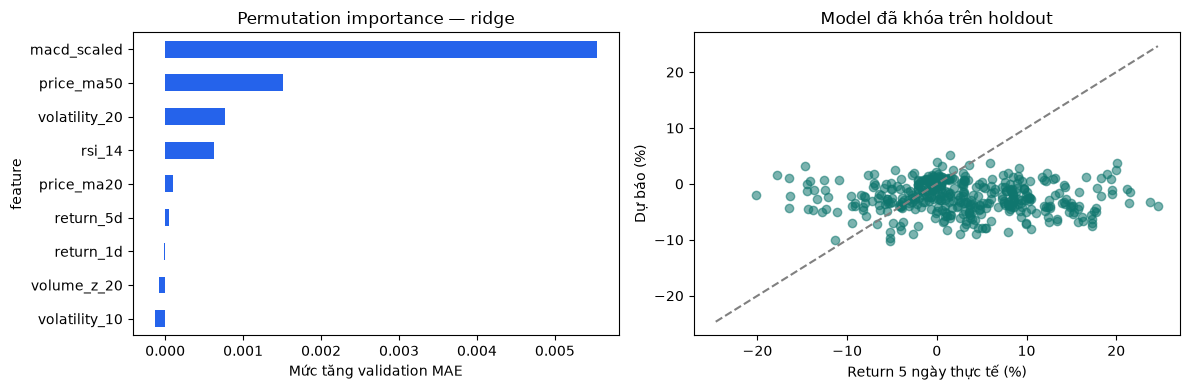

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
importance.sort_values("mae_increase").plot.barh(x="feature", y="mae_increase", ax=axes[0], legend=False, color="#2563eb")
axes[0].set(title=f"Permutation importance — {interpreted_name}", xlabel="Mức tăng validation MAE")
axes[1].scatter(preds["actual"] * 100, preds["prediction"] * 100, alpha=.55, color="#0f766e")
limit = float(max(preds.actual.abs().max(), preds.prediction.abs().max()) * 100)
axes[1].plot([-limit, limit], [-limit, limit], "--", color="gray")
axes[1].set(title="Model đã khóa trên holdout", xlabel="Return 5 ngày thực tế (%)", ylabel="Dự báo (%)")
plt.tight_layout(); plt.show()

In [5]:
worst = preds.nlargest(5, "absolute_error")[["date", "actual", "prediction", "absolute_error"]]
interpretation = {
    "selected_model": metrics_report["selected_model"],
    "interpreted_proxy": interpreted_name,
    "top_features": importance.head(3)["feature"].tolist(),
    "highest_error_regime": error_by_volatility["mae"].idxmax(),
    "limitation": "chỉ technical feature không giải thích được biến động mạnh do sự kiện; không khẳng định quan hệ nhân quả hay mức độ phù hợp đầu tư",
}
display(worst)
print(json.dumps(interpretation, indent=2))

,date,actual,prediction,absolute_error
90,2025-04-08,0.246463,-0.039266,0.285729
352,2026-04-09,0.238045,-0.032958,0.271003
270,2025-12-16,0.173065,-0.075591,0.248656
353,2026-04-10,0.214005,-0.034333,0.248338
271,2025-12-17,0.172476,-0.070048,0.242524


{
  "selected_model": "gru_rnn",
  "interpreted_proxy": "ridge",
  "top_features": [
    "macd_scaled",
    "price_ma50",
    "volatility_20"
  ],
  "highest_error_regime": "high",
  "limitation": "ch\u1ec9 technical feature kh\u00f4ng gi\u1ea3i th\u00edch \u0111\u01b0\u1ee3c bi\u1ebfn \u0111\u1ed9ng m\u1ea1nh do s\u1ef1 ki\u1ec7n; kh\u00f4ng kh\u1eb3ng \u0111\u1ecbnh quan h\u1ec7 nh\u00e2n qu\u1ea3 hay m\u1ee9c \u0111\u1ed9 ph\u00f9 h\u1ee3p \u0111\u1ea7u t\u01b0"
}
